In [1]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv("./College basketball csvs/cbb.csv")



In [2]:
df.describe() # Meta Data


,G,W,ADJOE,ADJDE,BARTHAG,EFG_O,EFG_D,TOR,TORD,ORB,...,FTR,FTRD,2P_O,2P_D,3P_O,3P_D,ADJ_T,WAB,SEED,YEAR
count,3885.000000,3885.000000,3885.000000,3885.000000,3885.000000,3885.000000,3885.000000,3885.000000,3885.000000,3885.000000,...,3885.000000,3885.000000,3885.000000,3885.000000,3885.000000,3885.000000,3885.000000,3885.000000,748.000000,3885.000000
mean,30.531532,16.075418,103.339743,103.341519,0.493928,49.935856,50.125946,18.551223,18.483115,29.267310,...,34.384813,34.645766,49.224402,49.388880,34.141133,34.319614,67.712227,-7.639967,8.798128,2018.403604
std,3.809623,6.506570,7.315009,6.490684,0.255374,3.079803,2.855079,2.145057,2.289045,4.201366,...,5.465945,6.337450,3.416380,3.290915,2.713812,2.406306,3.037251,6.826502,4.671615,3.583747
min,5.000000,0.000000,76.600000,84.000000,0.005000,39.200000,39.600000,11.900000,10.200000,14.400000,...,19.600000,16.200000,37.700000,37.700000,24.700000,26.100000,57.200000,-25.200000,1.000000,2013.000000
25%,29.000000,11.000000,98.300000,98.600000,0.281200,47.900000,48.200000,17.100000,16.900000,26.500000,...,30.500000,30.100000,46.900000,47.200000,32.300000,32.700000,65.700000,-12.600000,5.000000,2015.000000
50%,31.000000,16.000000,103.000000,103.500000,0.474000,49.900000,50.100000,18.500000,18.400000,29.300000,...,34.200000,34.000000,49.200000,49.400000,34.100000,34.300000,67.600000,-8.100000,9.000000,2018.000000
75%,33.000000,21.000000,108.100000,108.000000,0.716400,52.000000,52.000000,19.900000,19.900000,32.000000,...,38.000000,38.600000,51.400000,51.700000,35.900000,35.900000,69.700000,-3.000000,13.000000,2022.000000
max,40.000000,38.000000,129.100000,124.000000,0.984200,61.000000,60.100000,27.100000,28.500000,43.600000,...,58.600000,60.700000,64.000000,61.200000,44.100000,43.100000,83.400000,13.100000,16.000000,2024.000000


In [3]:
# Null Values
df.isnull().sum()[df.isnull().sum() > 0]

POSTSEASON    3137
SEED          3137
dtype: int64

In [4]:
df["POSTSEASON"] = df["POSTSEASON"].fillna("DNQ")
df["SEED"] = df["SEED"].fillna("UNRANKED")

In [5]:
df["CONF"].unique()

array(['ACC', 'B10', 'B12', 'WCC', 'SEC', 'BE', 'Amer', 'P12', 'A10',
       'MVC', 'AE', 'ASun', 'BSky', 'BSth', 'BW', 'CAA', 'CUSA', 'Horz',
       'Ind', 'Ivy', 'MAAC', 'MAC', 'MEAC', 'MWC', 'NEC', 'OVC', 'Pat',
       'SB', 'SC', 'Slnd', 'Sum', 'SWAC', 'WAC', 'ind', 'GWC'],
      dtype=object)

In [6]:
df.groupby("CONF")["TEAM"].count() # Teams for each stage

CONF
A10     157
ACC     162
AE      101
ASun    107
Amer    114
B10     150
B12     114
BE      119
BSky    124
BSth    120
BW      108
CAA     117
CUSA    146
GWC       5
Horz    113
Ind       1
Ivy      80
MAAC    120
MAC     132
MEAC    123
MVC     114
MWC     119
NEC     110
OVC     127
P12     132
Pat     108
SB      131
SC      113
SEC     154
SWAC    116
Slnd    130
Sum      98
WAC     106
WCC     108
ind       6
Name: TEAM, dtype: int64

In [7]:
df.groupby("POSTSEASON")["TEAM"].count() # Teams for each stage

POSTSEASON
2ND            11
Champions      11
DNQ          3137
E8             44
F4             22
R32           176
R64           352
R68            44
S16            88
Name: TEAM, dtype: int64

In [8]:

# Data Enriching
df["WIN_RATE"] = (df["W"] / df["G"]) 
df["IN_PLAYOFFS"] = df["POSTSEASON"] != "DNQ"
df["IN_PLAYOFFS"] = df["IN_PLAYOFFS"].astype(int)

In [9]:
# Get all rows where WIN_RATE > 1
# Data Integrity

df = df[df["WIN_RATE"] <= 1]


Text(0, 0.5, '3 Point Percentage')

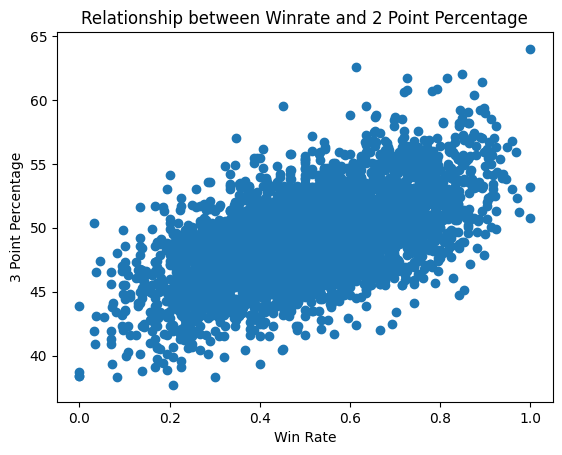

In [12]:
plt.scatter(df["WIN_RATE"],df["2P_O"])

plt.title("Relationship between Winrate and 2 Point Percentage")
plt.xlabel("Win Rate")
plt.ylabel("3 Point Percentage")

KeyError: ''

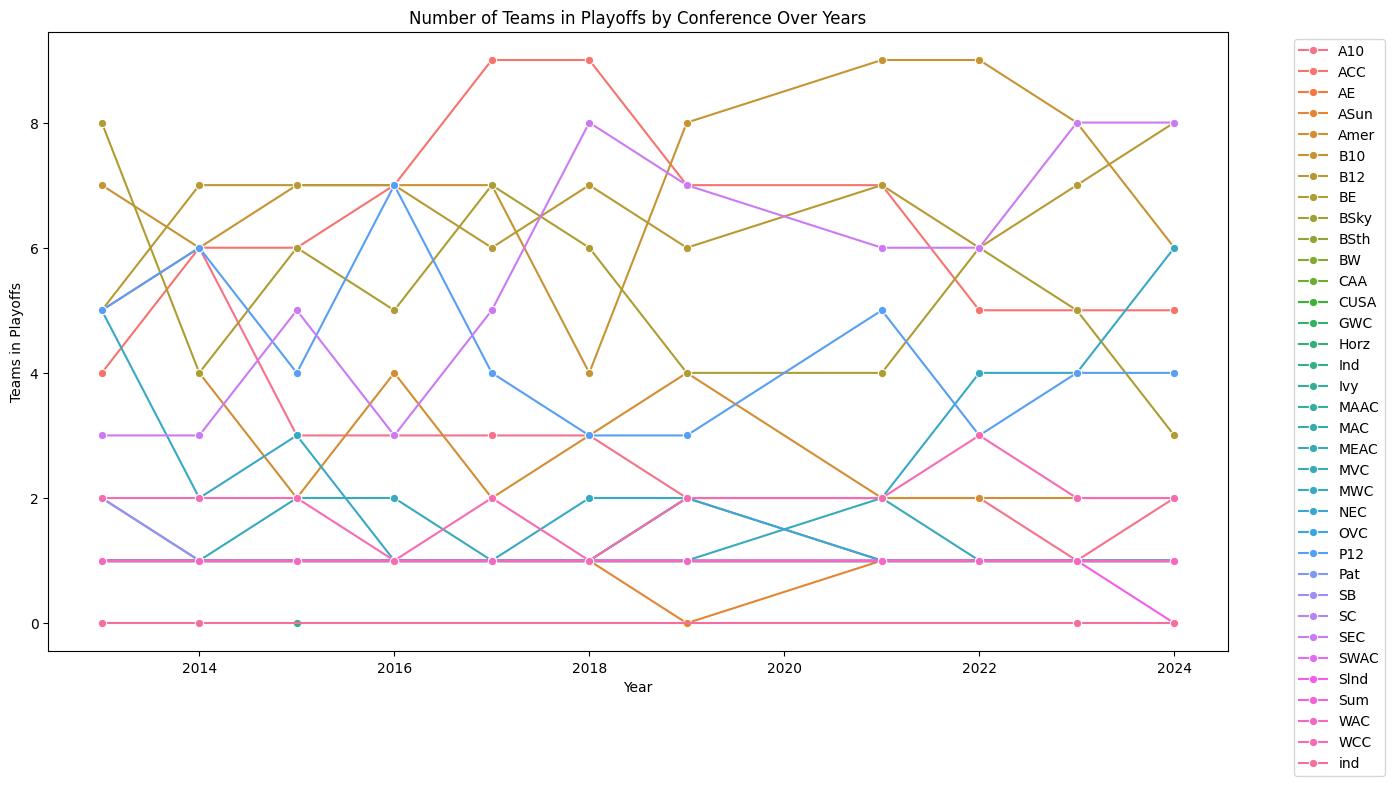

In [ ]:
# Suppose you already have
df_grouped = df.groupby(["CONF","YEAR"])["IN_PLAYOFFS"].sum().reset_index()

plt.figure(figsize=(14,8))
sns.lineplot(
    data=df_grouped,
    x="YEAR",
    y="IN_PLAYOFFS",
    hue="CONF",
    marker="o"
)

plt.title("Number of Teams in Playoffs by Conference Over Years")
plt.ylabel("Teams in Playoffs")
plt.xlabel("Year")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # move legend outside
plt.tight_layout()
plt.show()